In [ ]:
import sklearn          # machine learning toolkit (algorithms, metrics, preprocessing)
import tensorflow as tf # main deep learning framework, aliased as 'tf' for convenience
from tensorflow import keras  # high-level API built on top of tensorflow for building neural nets
                              # imported directly so you can use keras.layers, keras.models etc
                              # instead of tf.keras.layers, tf.keras.models, etc.
import warnings               # python's built-in warning control module
warnings.filterwarnings('ignore')  # suppress non-critical warnings from cluttering output
                                   # common in ML code since libraries are verbose about deprecations

In [ ]:
from sklearn import datasets  # imports sklearn's built-in toy datasets (iris, mnist, boston etc)
                              # used to quickly get sample data without downloading anything
import numpy as np            # numerical computing library, aliased as 'np' by convention
                              # core tool for array/matrix operations that ML math relies on
import pandas as pd           # data manipulation library, aliased as 'pd' by convention
                              # used for loading, cleaning and exploring data in table format (DataFrames)

# Load the wine dataset
wine = datasets.load_wine()

# Convert to pandas DataFrame, essentially a 2D table with rows, columns and labeled axes
# The main difference from a plain numpy array is that pandas adds all the convenience around it — named columns, 
# handling missing values, filtering, grouping, merging tables etc. 
# Under the hood a DataFrame is actually built on top of numpy arrays.
df = pd.DataFrame(data=np.c_[wine['data'], wine['target']], columns=wine['feature_names'] + ['target'])
df.shape

#### Data Summary

In [ ]:
# Goal: The model learns the relationship between the 14 features and the wine class during training
# Then we test it by feeding it just the 14 features from the test set and seeing if it can correctly predict the class
# without being given the answer
print(f"Size: {df.shape[1]} samples with  {df.shape[1]} columns/features")
print(f"Features: {df.columns.tolist()[::-1]}")
targets = df.target.unique().astype(int).tolist()
print(f"Classification Targets: { targets}");
print(f"Target Names: {wine.target_names}");


#### Data Preview

In [ ]:
# Display the DataFrame
print("Data Preview")
df.head()

In [ ]:
# Plot a histogram of the 'alcohol' feature
import matplotlib.pyplot as plt
plt.hist(df['alcohol'], bins=10, alpha=0.5)
plt.xlabel('Alcohol')
plt.ylabel('Count')
plt.title('Histogram of Alcohol in Wine Samples')
plt.show()

In [ ]:
# Split the data into training and test sets
# Reserving 20% of the data as unseen test data so we can honestly evaluate how well the model generalizes after training on the other 80%.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(wine.data, wine.target, test_size=0.2, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


# Create and train a decision tree
# A decision tree is a flowchart of yes/no questions about the data that leads to a prediction at the end
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)

# Make predictions on the test set and calculate the accuracy
# Run the trained model against data it hasn't seen before, then measure what percentage of its predictions were correct
y_pred_tree = tree.predict(X_test)
accuracy_tree = accuracy_score(y_test, y_pred_tree)
print(f"Decision Tree Accuracy: {accuracy_tree:.2f}", )

# utility function to draw confusion matrix with maplotlon
# A confusion matrix is a table showing how often the model predicted each class correctly vs what it actually got confused with.
def show_confusion_matrix(y_test, y_pred):
    cfm = confusion_matrix(y_test, y_pred)
    cm_display = ConfusionMatrixDisplay(cfm, display_labels=wine.target_names)
    cm_display.plot(cmap="Blues")


# Show confusion matrix for the decision tree
show_confusion_matrix(y_test, y_pred_tree)

In [ ]:
    # Now let's create and train a random forest classifier
    from sklearn.ensemble import RandomForestClassifier
    forest = RandomForestClassifier(n_estimators=100, random_state=42)
    forest.fit(X_train, y_train)

    # Make predictions on the test set and calculate the accuracy
    y_pred_forest = forest.predict(X_test)

    accuracy_forest = accuracy_score(y_test, y_pred_forest)
    print(f"Random Forest Accuracy: {accuracy_forest:.2f}", )

    show_confusion_matrix(y_test, y_pred_forest )

In [ ]:
# Visualize which of the 14 wine features the random forest relied on most when making its predictions
importance=forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_],
             axis=0)
indices = np.argsort(importance)
# Plot the feature importances of the forest
plt.figure()
plt.title("Feature importances")
plt.barh(range(wine.data.shape[1]), importance[indices],
       color="b",  align="center")

plt.yticks(range(wine.data.shape[1]), df.columns[:-1].tolist())
plt.ylim([0, wine.data.shape[1]])
plt.show()


In [ ]:
# Import the tools needed to normalize the input data and build a simple neural network with fully connected layers
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Standardize the features to have mean=0 and variance=1
scaler = StandardScaler()
data = scaler.fit_transform(wine.data)

# Convert targets to categorical (one-hot encoding)
targets = to_categorical(wine.target)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(data, targets, test_size=0.2, random_state=42)

# Create a Sequential model
model = Sequential()
model.add(Dense(13, activation='relu', input_shape=(13,)))
model.add(Dense(3, activation='softmax'))

# Compile the model with 'categorical_crossentropy' loss function and 'adam' optimizer
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model for 20 epochs
model.fit(X_train, y_train, epochs=20, batch_size=1, verbose=1)

#### Predict and evaluate the Model

In [ ]:
# Make predictions on the test set and calculate the accuracy
y_pred_mlp = np.argmax(model.predict(X_test), axis=-1)
accuracy_mlp = accuracy_score(np.argmax(y_test, axis=-1), y_pred_mlp)
print("MLP Accuracy:", accuracy_mlp)



MLP Confusion Matrix:



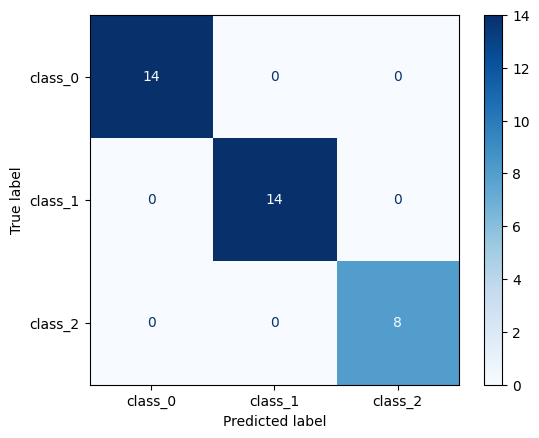

In [40]:
# Print the confusion matrix for the MLP
print("MLP Confusion Matrix:")
cfn=confusion_matrix(np.argmax(y_test, axis=-1), y_pred_mlp)
print()
show_confusion_matrix(np.argmax(y_test, axis=-1),  y_pred_mlp )